In [233]:
import pandas as pd
from sklearn import preprocessing

#### load data, clean data

In [236]:
# Column names. All were taken from the source page.

columns = (['Age', 'Class of Worker', 'Industry Code', 'Occipation Code', 'Education', 'School Enrollment Last Week',
  'Martial Status', 'Major Industry Code', 'Major Occupation Code', 'Race', 'Hispanic Origin', 'Sex',
  'Union Membership', 'Reason for Unemployment', 'FT/PT Employment', 'Capital Gains', 'Capital Losses',
  'Stock Dividends', 'Tax Filer Status', 'Region of Previous Residence', 'State of Previous Residence',
  'Household and Family Status', 'Household Summary', 'Instance Weight', 'Migration Code-Change in MSA',
  'Migration Code-Change in REG', 'Migration Code-Move in REG', 'Lived in Same House 1 Year Ago',
  'Migration Previous Residence in Sunbelt', 'Number of Persons Worked for Employer', 'Family Members Under 18',
  'Father Birth Country', 'Mother Birth Country', 'Self Birth Country', 'Citizenship', 'Owns Business or Self-Employed',
  'Veterans Questionnaire', 'Veteran Benefits', 'Workweeks/Year', 'Below or Above $50k', 'Wage/HR', '94 or 95'])

In [238]:
df1 = pd.read_csv('census-income.data', header=None, names=columns)

In [239]:
df1

,Age,Class of Worker,Industry Code,Occipation Code,Education,School Enrollment Last Week,Martial Status,Major Industry Code,Major Occupation Code,Race,...,Mother Birth Country,Self Birth Country,Citizenship,Owns Business or Self-Employed,Veterans Questionnaire,Veteran Benefits,Workweeks/Year,Below or Above $50k,Wage/HR,94 or 95
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorporated,37,2,11th grade,0,Not in universe,Married-civilian spouse present,Business and repair services,Executive admin and managerial,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
199520,47,Not in universe,0,0,Some college but no degree,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Poland,Poland,Germany,Foreign born- U S citizen by naturalization,0,Not in universe,2,52,95,- 50000.
199521,16,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.


In [240]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# list categorical and numerical columns seperately so they can be imputed on their own
categorical_columns = df1.select_dtypes(include=['category', 'object']).columns
numerical_columns = df1.select_dtypes(include=['int64', 'float64']).columns

# do the impution
categorical_imputer = SimpleImputer(strategy='most_frequent')  # For categorical columns
numerical_imputer = SimpleImputer(strategy='median')  # For numerical columns

df1[categorical_columns] = categorical_imputer.fit_transform(df1[categorical_columns])
df1[numerical_columns] = numerical_imputer.fit_transform(df1[numerical_columns])

In [241]:
# I will label encode all the selected categorical columns

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to each categorical column
for col in categorical_columns:
    df1[col] = label_encoder.fit_transform(df1[col])

In [246]:
# checking df again after all transformations
df1

,Age,Class of Worker,Industry Code,Occipation Code,Education,School Enrollment Last Week,Martial Status,Major Industry Code,Major Occupation Code,Race,...,Mother Birth Country,Self Birth Country,Citizenship,Owns Business or Self-Employed,Veterans Questionnaire,Veteran Benefits,Workweeks/Year,Below or Above $50k,Wage/HR,94 or 95
0,73.0,3,0.0,0.0,12,0.0,2,6,14,6,...,40,40,40,4,0.0,1,2.0,0.0,95.0,0
1,58.0,6,4.0,34.0,16,0.0,2,0,4,8,...,40,40,40,4,0.0,1,2.0,52.0,94.0,0
2,18.0,3,0.0,0.0,0,0.0,1,4,14,6,...,41,41,41,0,0.0,1,2.0,0.0,95.0,0
3,9.0,3,0.0,0.0,10,0.0,2,4,14,6,...,40,40,40,4,0.0,1,0.0,0.0,94.0,0
4,10.0,3,0.0,0.0,10,0.0,2,4,14,6,...,40,40,40,4,0.0,1,0.0,0.0,94.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87.0,3,0.0,0.0,5,0.0,2,2,14,6,...,2,40,40,4,0.0,1,2.0,0.0,95.0,0
199519,65.0,5,37.0,2.0,1,0.0,2,2,2,2,...,40,40,40,4,0.0,1,2.0,52.0,94.0,0
199520,47.0,3,0.0,0.0,16,0.0,2,2,14,6,...,32,32,11,1,0.0,1,2.0,52.0,95.0,0
199521,16.0,3,0.0,0.0,0,0.0,1,4,14,6,...,40,40,40,4,0.0,1,2.0,0.0,95.0,0


#### 2 - split data and train model

In [249]:
# sepeare datasets into features (x) and labels (y)
y = df1['Below or Above $50k']  
X = df1.drop(columns=['Below or Above $50k']) 

In [251]:
# verify 
print("Features/X:", X.shape)
print("Labels/Y:", y.shape)

Features/X: (199523, 41)
Labels/Y: (199523,)


In [253]:
from sklearn.model_selection import train_test_split

# split data into 70:30 with test_train_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# verify variable shapes
print("X_train and y_train shape", X_train.shape, y_train.shape)
print("X_test and y_test shape", X_test.shape, y_test.shape)

X_train and y_train shape (139666, 41) (139666,)
X_test and y_test shape (59857, 41) (59857,)


In [285]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# begin building the tree with a max depth of 3
clf = DecisionTreeClassifier(max_depth=3)

# use training data to train the tree
clf.fit(X_train, y_train)

# y_predict will hold predictions generated
y_predict = clf.predict(X_test)

# evaluation metrics
accuracy = accuracy_score(y_test, y_predict)
evaluation = classification_report(y_test, y_predict, zero_division=0)
print("Accuracy:", accuracy)
print("\nStatistics:\n", evaluation)

Accuracy: 0.8338038992933158

Statistics:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     28973
         1.0       0.00      0.00      0.00       126
         2.0       0.00      0.00      0.00       148
         3.0       0.00      0.00      0.00       126
         4.0       0.00      0.00      0.00       223
         5.0       0.00      0.00      0.00       105
         6.0       0.00      0.00      0.00       201
         7.0       0.00      0.00      0.00        38
         8.0       0.00      0.00      0.00       344
         9.0       0.00      0.00      0.00        71
        10.0       0.00      0.00      0.00       210
        11.0       0.00      0.00      0.00        24
        12.0       0.12      0.26      0.17       532
        13.0       0.00      0.00      0.00       132
        14.0       0.00      0.00      0.00        77
        15.0       0.00      0.00      0.00        95
        16.0       0.00      0.00     

#### 3 - visualize tree using plot_tree

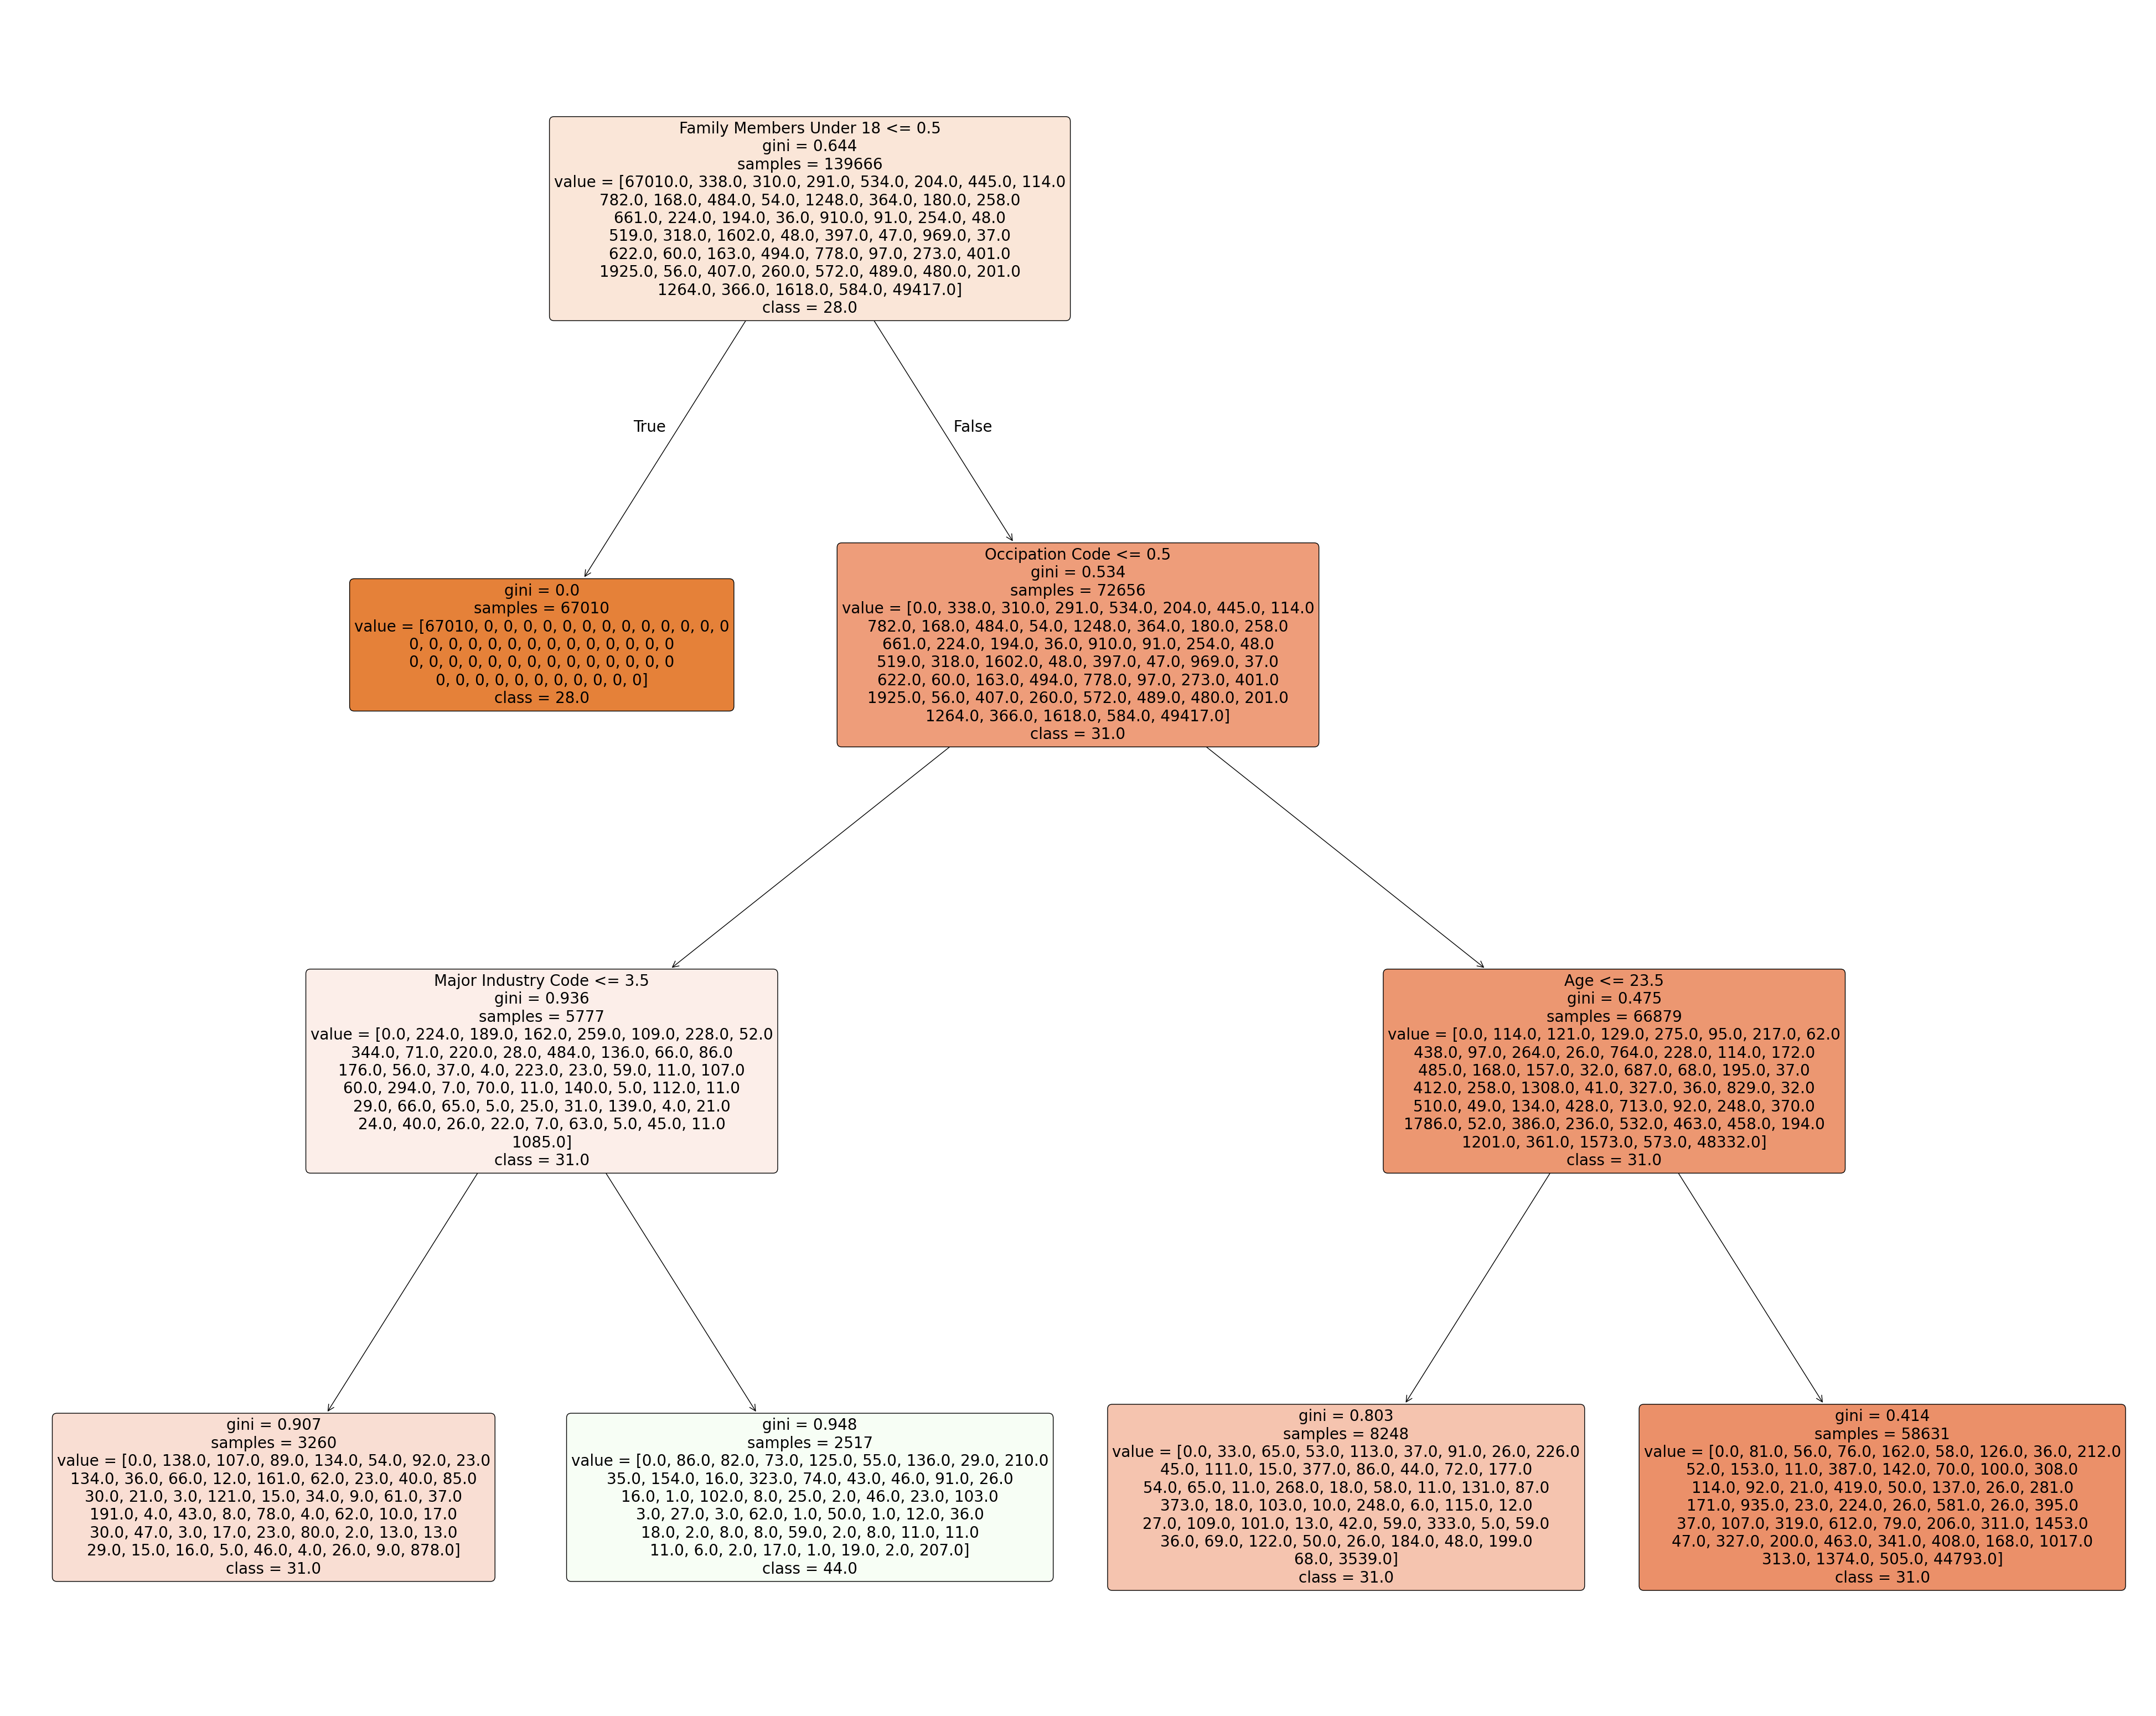

In [258]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# I had to fix indexing errors in my labels to get the plot to show.
# i will find all uniques in y_train and put them in uniques
uniques = y_train.unique()
# then i will loop through elements in uniques to put them in a string, this will form a new list
class_names = [str(cls) for cls in unique_classes]

# generate tree plot
plt.figure(figsize=(50, 40))
plot_tree(clf, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=20, max_depth=3)
plt.show()

#### 4 - Feature Importance
##### print importance score for each feature using feature_importances_ on the dt clf, then discuss why one feature may appear most important

In [261]:
# print the importance score for each featue using feature_importances_attribute
feature_importances = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': clf.feature_importances_
})

# using the attribute, find all feature importances and then print them for discussion
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

                                    Feature  Importance
30                  Family Members Under 18    0.952586
3                           Occipation Code    0.030308
0                                       Age    0.015876
7                       Major Industry Code    0.001230
31                     Father Birth Country    0.000000
24             Migration Code-Change in MSA    0.000000
25             Migration Code-Change in REG    0.000000
26               Migration Code-Move in REG    0.000000
27           Lived in Same House 1 Year Ago    0.000000
28  Migration Previous Residence in Sunbelt    0.000000
29    Number of Persons Worked for Employer    0.000000
33                       Self Birth Country    0.000000
32                     Mother Birth Country    0.000000
22                        Household Summary    0.000000
34                              Citizenship    0.000000
35           Owns Business or Self-Employed    0.000000
36                   Veterans Questionnaire    0

The highest feature importance on the list is family members under 18 (0.952586). This implies that having dependents who are minors is a major factor in determining income levels for households. An insight on this dataset derived from this is that the having a child/minor-dependent in a household is a factor that majorly contributes to the model's prediction.

#### Part 5 - Evaluation on the test

In [265]:
df_test = pd.read_csv('census-income.test', header=None, names=columns)
df_test.head()

,Age,Class of Worker,Industry Code,Occipation Code,Education,School Enrollment Last Week,Martial Status,Major Industry Code,Major Occupation Code,Race,...,Mother Birth Country,Self Birth Country,Citizenship,Owns Business or Self-Employed,Veterans Questionnaire,Veteran Benefits,Workweeks/Year,Below or Above $50k,Wage/HR,94 or 95
0,38,Private,6,36,1st 2nd 3rd or 4th grade,0,Not in universe,Married-civilian spouse present,Manufacturing-durable goods,Machine operators assmblrs & inspctrs,...,Mexico,Mexico,Mexico,Foreign born- Not a citizen of U S,0,Not in universe,2,12,95,- 50000.
1,44,Self-employed-not incorporated,37,12,Associates degree-occup /vocational,0,Not in universe,Married-civilian spouse present,Business and repair services,Professional specialty,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,26,95,- 50000.
2,2,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
3,35,Private,29,3,High school graduate,0,Not in universe,Divorced,Transportation,Executive admin and managerial,...,United-States,United-States,United-States,Native- Born in the United States,2,Not in universe,2,52,94,- 50000.
4,49,Private,4,34,High school graduate,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,50,95,- 50000.


In [267]:
# do the same processing routine i did with the original dataset
# list categorical and numerical columns seperately so they can be imputed on their own
categorical_columns2 = df_test.select_dtypes(include=['category', 'object']).columns
numerical_columns2 = df_test.select_dtypes(include=['int64', 'float64']).columns

# do the impution
categorical_imputer2 = SimpleImputer(strategy='most_frequent')  # For categorical columns
numerical_imputer2 = SimpleImputer(strategy='median')  # For numerical columns

df_test[categorical_columns2] = categorical_imputer2.fit_transform(df_test[categorical_columns2])
df_test[numerical_columns2] = numerical_imputer2.fit_transform(df_test[numerical_columns2])

In [269]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to each categorical column
for col in categorical_columns2:
    df_test[col] = label_encoder.fit_transform(df_test[col])

In [271]:
df_test.head()

,Age,Class of Worker,Industry Code,Occipation Code,Education,School Enrollment Last Week,Martial Status,Major Industry Code,Major Occupation Code,Race,...,Mother Birth Country,Self Birth Country,Citizenship,Owns Business or Self-Employed,Veterans Questionnaire,Veteran Benefits,Workweeks/Year,Below or Above $50k,Wage/HR,94 or 95
0,38.0,4,6.0,36.0,3,0.0,2,2,10,5,...,26,26,26,0,0.0,1,2.0,12.0,95.0,0
1,44.0,6,37.0,12.0,8,0.0,2,2,2,10,...,40,40,40,4,0.0,1,2.0,26.0,95.0,0
2,2.0,3,0.0,0.0,10,0.0,2,4,14,6,...,40,40,40,4,0.0,1,0.0,0.0,95.0,0
3,35.0,4,29.0,3.0,12,0.0,2,0,21,2,...,40,40,40,4,2.0,1,2.0,52.0,94.0,0
4,49.0,4,4.0,34.0,12,0.0,2,0,4,8,...,40,40,40,4,0.0,1,2.0,50.0,95.0,0


In [273]:
# sepeare datasets into features (x) and labels (y)
y2 = df_test['Below or Above $50k']  
X2 = df_test.drop(columns=['Below or Above $50k']) 

# split data into 70:30 with test_train_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [287]:
# begin building the tree with a max depth of 3
clf2 = DecisionTreeClassifier(max_depth=3)

# use training data to train the tree
clf2.fit(X_train2, y_train2)

# y_predict will hold predictions generated
y_predict2 = clf2.predict(X_test2)

# evaluation metrics
accuracy2 = accuracy_score(y_test2, y_predict2)
evaluation2 = classification_report(y_test2, y_predict2, zero_division=0)
print("Accuracy:", accuracy2)
print("\nStatistics:\n", evaluation2)

Accuracy: 0.8330381903839086

Statistics:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14349
         1.0       0.00      0.00      0.00        59
         2.0       0.00      0.00      0.00        73
         3.0       0.00      0.00      0.00        59
         4.0       0.00      0.00      0.00       110
         5.0       0.00      0.00      0.00        32
         6.0       0.00      0.00      0.00        92
         7.0       0.00      0.00      0.00        24
         8.0       0.00      0.00      0.00       155
         9.0       0.00      0.00      0.00        36
        10.0       0.00      0.00      0.00       121
        11.0       0.00      0.00      0.00        12
        12.0       0.13      0.26      0.17       279
        13.0       0.00      0.00      0.00        77
        14.0       0.00      0.00      0.00        42
        15.0       0.00      0.00      0.00        61
        16.0       0.00      0.00     

In [277]:
# print the importance score for each featue using feature_importances_attribute
feature_importances2 = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': clf2.feature_importances_
})

# using the attribute, find all feature importances and then print them for discussion
feature_importances2 = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances2)

                                    Feature  Importance
30                  Family Members Under 18    0.952586
3                           Occipation Code    0.030308
0                                       Age    0.015876
7                       Major Industry Code    0.001230
12                         Union Membership    0.000000
2                             Industry Code    0.000000
4                                 Education    0.000000
5               School Enrollment Last Week    0.000000
6                            Martial Status    0.000000
8                     Major Occupation Code    0.000000
9                                      Race    0.000000
10                          Hispanic Origin    0.000000
1                           Class of Worker    0.000000
21              Household and Family Status    0.000000
13                  Reason for Unemployment    0.000000
14                         FT/PT Employment    0.000000
15                            Capital Gains    0